# 04 · 全整数 INT8 量化与回归验证

**对应阶段 4**。本章沿用阶段 3 的冻结权重，先验证浮点框架转换，再用训练池校准 INT8，最后评估精度。默认读取仓库内真实实验报告，不触发训练；你也可以开启转换开关在本机重新导出。

仍在 `CNN-Tutorial` Jupyter kernel 中阅读。TensorFlow 转换通过独立环境的 Python 子进程运行，避免改变 PyTorch/CUDA 依赖。

In [1]:
from pathlib import Path
import json, os, subprocess, sys
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "cnn_tutorial").is_dir():
    ROOT = ROOT.parent
assert (ROOT / "cnn_tutorial").is_dir(), "请从项目根目录或 notebooks 启动"
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
ARCHIVE = ROOT / "docs/05_experiments/v0.3"
MODEL_DIR = ROOT / "artifacts/v0.3-int8"
RUN_CONVERSION = False
print("项目：", ROOT.name)


项目： CNN-Tutorial


## 1. 冻结输入与数据边界

交换文件 `weights.npz` 只保存权重；`calibration.npz` 来自训练池的 300 张图；`evaluation.npz` 保存 372 张官方测试图、标签和 PyTorch logits。测试图只做回归评估。下面的清单有输入文件哈希，可识别是否误用了其他权重。

本章使用已观察过的公开合成数据，成绩不能代替真实摄像头测试。

In [2]:
source = json.loads((ARCHIVE / "conversion_manifest.json").read_text(encoding="utf-8"))
print("类别索引：", dict(enumerate(source["classes"])))
print("校准来源：", source["calibration_source"], source["calibration_samples"])
print("评估来源：", source["evaluation_source"], source["evaluation_samples"])
print("Checkpoint SHA256：", source["checkpoint_sha256"])


类别索引： {0: 'paper', 1: 'rock', 2: 'scissors'}
校准来源： training split only 300
评估来源： official test; never calibration 372
Checkpoint SHA256： ed3e422f75b1765953cddc91fd49ab0f140e43f5c2c72e2a69785930365972ad


## 2. 权重布局变换为何不改变函数

卷积核从 OIHW 换成 HWIO。Flatten 后的分类头更容易出错：PyTorch 按 CHW 展开，而 Keras 按 HWC 展开，因此必须同时重排分类权重。下面用一个很小的张量演示同一线性函数在两种布局下应给出相同结果。真正转换还会在全部测试图上检查 logits 一致性。

In [3]:
from cnn_tutorial.quantization import dense_chw_to_hwc
features = np.arange(12, dtype=np.float32).reshape(1, 2, 2, 3)
weight = np.arange(36, dtype=np.float32).reshape(3, 12) / 36
chw_result = features.reshape(1, -1) @ weight.T
hwc_result = features.transpose(0, 2, 3, 1).reshape(1, -1) @ dense_chw_to_hwc(weight, 2, 2, 3)
np.testing.assert_allclose(chw_result, hwc_result)
print("CHW:", chw_result, "HWC:", hwc_result)


CHW: [[14.055556 36.055557 58.055557]] HWC: [[14.055555 36.055557 58.055557]]


## 3. 可选：执行真实转换

先按 [量化教程](../docs/04_deployment/int8_conversion.md) 创建 `CNN-Tutorial-Quant` 并安装 `requirements-quant.txt`。在训练环境执行 `python scripts/prepare_conversion.py` 准备交换文件。本机已完成这一步。

把第一节 `RUN_CONVERSION` 改为 `True` 会调用量化环境；输出使用新的时间戳目录。默认推断同一 conda 的相邻环境路径，也允许环境变量 `CNN_QUANT_PYTHON` 指定绝对路径。`subprocess.run(..., check=True)` 会在转换失败时中断，不会继续展示为成功。

In [4]:
if RUN_CONVERSION:
    filename = "python.exe" if os.name == "nt" else "bin/python"
    env_root = Path(sys.prefix).parent / "CNN-Tutorial-Quant"
    quant_python = Path(os.environ.get("CNN_QUANT_PYTHON", str(env_root / filename)))
    assert quant_python.is_file(), "找不到量化环境 Python，请设置 CNN_QUANT_PYTHON"
    MODEL_DIR = ROOT / "artifacts" / ("v0.3-int8-" + datetime.now().strftime("%Y%m%d-%H%M%S"))
    subprocess.run([str(quant_python), str(ROOT / "scripts/convert_int8.py"),
                    "--output-dir", str(MODEL_DIR)], cwd=ROOT, check=True)
    subprocess.run([str(quant_python), str(ROOT / "scripts/verify_golden.py"), str(MODEL_DIR)], cwd=ROOT, check=True)
    REPORT_DIR = MODEL_DIR
else:
    REPORT_DIR = ARCHIVE
    print("读取已归档的真实量化实验；没有启动转换。")
report = json.loads((REPORT_DIR / "report.json").read_text(encoding="utf-8"))
assert report["acceptance_drop_at_most_2pp"]
print("FP32 logits 最大绝对误差：", report["float_max_absolute_error"])
print("模型：", report["bytes"], "bytes；SHA256：", report["tflite_sha256"])


读取已归档的真实量化实验；没有启动转换。
FP32 logits 最大绝对误差： 1.049041748046875e-05
模型： 33240 bytes；SHA256： 7891518a9b70ec6b3be8649123651780ce87ede1e69a9a49c394c17d203a0baa


## 4. 先检查图，再解释准确率

全整数模型允许 INT8 激活/权重与 INT32 偏置/形状常量；不应出现浮点张量或自定义算子。算子版本来自序列化 FlatBuffer，不能把厂商分析日志中的 `:3` 当作版本号。桌面审计和厂商分析器通过，仍需在目标 TFLite Micro 库中核对算子注册。

In [5]:
audit = json.loads((REPORT_DIR / "graph_audit.json").read_text(encoding="utf-8"))
print("schema:", audit["schema_version"], "张量类型：", audit["tensor_type_counts"])
for op in audit["operator_codes"]:
    print(op["name"], "version", op["version"])
assert audit["float_tensors"] == 0 and audit["custom_ops"] == 0
print("arena:", audit["arena_bytes"], "（需目标端实测）")


schema: 3 张量类型： {'INT8': 14, 'INT32': 5}
CONV_2D version 3
MAX_POOL_2D version 2
AVERAGE_POOL_2D version 2
RESHAPE version 1
FULLY_CONNECTED version 4
arena: None （需目标端实测）


## 5. 对同一测试集比较精度

验收标准为相对 FP32 下降不超过 **2 个百分点**。混淆矩阵的行是真实类别，列是预测类别。除了总准确率，也看每类召回率：当前 paper 类仍是主要误差来源。这里评估的是冻结后的模型，没有用这些结果重新挑选量化配置。

FP32: 95.70%
INT8: 95.43%；下降 0.269 个百分点
INT8 macro-F1: 0.9535


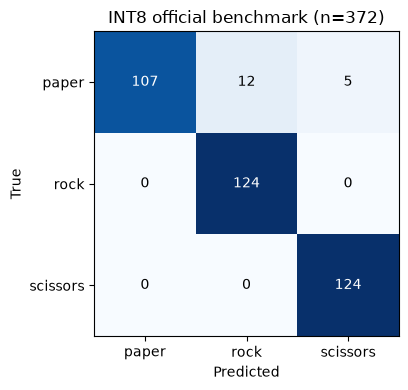

In [6]:
print(f"FP32: {report['fp32_accuracy']:.2%}")
print(f"INT8: {report['int8_accuracy']:.2%}；下降 {report['accuracy_drop_percentage_points']:.3f} 个百分点")
print(f"INT8 macro-F1: {report['int8_macro_f1']:.4f}")
cm = np.asarray(report["int8_confusion_matrix"])
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm, cmap="Blues")
ax.set(xticks=range(3), yticks=range(3), xticklabels=report["classes"], yticklabels=report["classes"],
       xlabel="Predicted", ylabel="True", title="INT8 official benchmark (n=372)")
for (i, j), value in np.ndenumerate(cm):
    ax.text(j, i, str(value), ha="center", va="center", color="white" if value > 65 else "black")
plt.tight_layout()
plt.show()


## 6. uint8 像素如何变成模型输入

先完成与训练一致的灰度和 64×64 缩放，然后使用实际 scale 和 zero point。`np.rint` 使用最近偶数舍入，`clip` 防止数值绕回。本次模型的 scale 约为 1/255、zero point 为 -128；下面穷举 256 个灰度值，验证本次模型可把缩放后的 8 位灰度减去 128。这个捷径只在本次契约满足时成立，未来换模型要重新检查。

In [7]:
from cnn_tutorial.quantization import quantize_int8
q = report["input_quantization"]
pixels = np.arange(256, dtype=np.float32)
mapped = quantize_int8(pixels / 255, q["scale"], q["zero_point"])
np.testing.assert_array_equal(mapped.astype(np.int16), pixels.astype(np.int16) - 128)
print("全部 256 个灰度值通过映射验证：", mapped[[0, 127, 128, 255]])
print("输出量化参数：", report["output_quantization"])


全部 256 个灰度值通过映射验证： [-128   -1    0  127]
输出量化参数： {'scale': 0.14151470363140106, 'zero_point': 4, 'dtype': 'int8'}


## 7. Golden vectors 与阶段边界

每类取官方测试集里第一张图作为静态回放样本，保存有符号 INT8 输入及输出字节。样本不参与校准。先验证文件哈希和模型身份，再在板上逐个回放，记录每个输出字节和 argmax；之后才连接摄像头。这里只读取实测桌面结果，不声称已做板端对齐。

下一步对应**阶段 5：板卡工程接入与静态向量对齐**；需要准确器件、工具版本、内存布局和现有 FPGA 工程。**阶段 6**才是连续视频、叠加与 15 FPS 实测。

In [8]:
golden_path = MODEL_DIR / "golden/manifest.json" if RUN_CONVERSION else ARCHIVE / "golden_manifest.json"
golden = json.loads(golden_path.read_text(encoding="utf-8"))
assert golden["model_sha256"] == report["tflite_sha256"]
for vector in golden["vectors"]:
    print(vector["true_class"], "->", vector["output_int8"], "预测：", vector["predicted_class"])
print("板卡兼容已验证：", report["board_compatibility_verified"])


paper -> [11, 0, -2] 预测： paper
rock -> [-1, 79, -60] 预测： rock
scissors -> [1, -75, 63] 预测： scissors
板卡兼容已验证： False


## 语法与函数速查

| 表达式 | 含义 |
|---|---|
| `transpose` / `reshape` | 分别重排轴、改变数组形状；二者不能混为一谈 |
| `np.rint` / `np.clip` | 舍入到最近偶数 / 限制数值范围 |
| `astype(np.int8)` | 转为有符号 8 位整数；必须先饱和截断 |
| `argmax` | 返回最大值索引；相同最大值返回第一个 |
| `check=True` | 子进程失败时抛出异常，阻止后续依赖步骤 |
| SHA-256 | 校验产物身份和完整性，不能证明模型准确性 |

来源与实现细节见 [阶段 4 文档](../docs/04_deployment/int8_conversion.md)。